In [5]:
import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [15]:
# ============================================================
# Config
# ============================================================

@dataclass
class Config:
    seed: int = 7
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Dataset
    n_total: int = 40_000
    train_fraction: float = 0.9
    balanced: bool = True
    square_halfwidth: float = 1.0     # tune if needed
    ball_radius: float = 0.5          # tune if needed

    # Training
    lr: float = 1e-2
    batch_size: int = 256
    max_epochs: int = 250
    target_val_acc: float = 0.98
    mse_target_scale: float = 1.0     # labels are +/- 1

    # Architectures for Fig. 2
    widths: Tuple[int, ...] = (10, 50, 250)
    depths: Tuple[int, ...] = (2, 4, 8, 12)

    # FTLE grid
    grid_n: int = 181
    quiver_stride: int = 12
    eps_eig: float = 1e-12

    # Plot
    cmap: str = "RdBu_r"
    vmin: float = -4.0
    vmax: float = 4.0

cfg = Config()

In [11]:
# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)


# ============================================================
# Dataset: balanced 2D ball classification
# target +1 inside ball, -1 outside
# ============================================================

def sample_balanced_ball_dataset(
    n_total: int,
    halfwidth: float,
    radius: float,
    seed: int = 0,
) -> Tuple[torch.Tensor, torch.Tensor]:
    g = torch.Generator().manual_seed(seed)

    n_pos = n_total // 2
    n_neg = n_total - n_pos

    pos = []
    neg = []

    while sum(x.shape[0] for x in pos) < n_pos or sum(x.shape[0] for x in neg) < n_neg:
        m = max(4096, n_total // 4)
        x = (2 * halfwidth) * torch.rand((m, 2), generator=g) - halfwidth
        r2 = (x ** 2).sum(dim=1)
        inside = r2 <= radius ** 2
        outside = ~inside

        if sum(t.shape[0] for t in pos) < n_pos:
            pos.append(x[inside])
        if sum(t.shape[0] for t in neg) < n_neg:
            neg.append(x[outside])

    x_pos = torch.cat(pos, dim=0)[:n_pos]
    x_neg = torch.cat(neg, dim=0)[:n_neg]

    y_pos = torch.ones((n_pos, 1))
    y_neg = -torch.ones((n_neg, 1))

    X = torch.cat([x_pos, x_neg], dim=0)
    y = torch.cat([y_pos, y_neg], dim=0)

    perm = torch.randperm(X.shape[0], generator=g)
    return X[perm], y[perm]


def train_test_split(
    X: torch.Tensor,
    y: torch.Tensor,
    train_fraction: float,
    seed: int = 0,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    g = torch.Generator().manual_seed(seed)
    n = X.shape[0]
    perm = torch.randperm(n, generator=g)
    n_train = int(train_fraction * n)
    idx_tr = perm[:n_train]
    idx_te = perm[n_train:]
    return X[idx_tr], y[idx_tr], X[idx_te], y[idx_te]


# ============================================================
# Model
# ============================================================

class FCNet(nn.Module):
    def __init__(self, width: int, depth: int):
        super().__init__()
        self.width = width
        self.depth = depth

        self.hidden = nn.ModuleList()
        in_dim = 2
        for _ in range(depth):
            layer = nn.Linear(in_dim, width, bias=True)
            self.hidden.append(layer)
            in_dim = width

        self.out = nn.Linear(width, 1, bias=True)
        self.act = torch.tanh

        self.reset_parameters()

    def reset_parameters(self):
        prev_dim = 2
        for layer in self.hidden:
            nn.init.normal_(layer.weight, mean=0.0, std=math.sqrt(1.0 / prev_dim))
            nn.init.zeros_(layer.bias)
            prev_dim = layer.out_features

        nn.init.normal_(self.out.weight, mean=0.0, std=math.sqrt(1.0 / prev_dim))
        nn.init.zeros_(self.out.bias)

    def hidden_representation(self, x: torch.Tensor) -> torch.Tensor:
        h = x
        for layer in self.hidden:
            h = self.act(layer(h))
        return h

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.hidden_representation(x)
        return self.out(h)


# ============================================================
# Training / evaluation
# ============================================================

def make_loader(X: torch.Tensor, y: torch.Tensor, batch_size: int, shuffle: bool):
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

@torch.no_grad()
def accuracy(model: nn.Module, X: torch.Tensor, y: torch.Tensor, device: str) -> float:
    model.eval()
    logits = model(X.to(device))
    pred = torch.sign(logits)
    pred[pred == 0] = 1
    acc = (pred.cpu() == y).float().mean().item()
    return acc

def train_model(
    width: int,
    depth: int,
    Xtr: torch.Tensor,
    ytr: torch.Tensor,
    Xte: torch.Tensor,
    yte: torch.Tensor,
    cfg: Config,
) -> Tuple[FCNet, Dict]:
    model = FCNet(width, depth).to(cfg.device)
    opt = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=0.0, weight_decay=0.0)
    loss_fn = nn.MSELoss()

    tr_loader = make_loader(Xtr, ytr, cfg.batch_size, shuffle=True)

    history = {"train_acc": [], "test_acc": [], "loss": []}

    for epoch in range(cfg.max_epochs):
        model.train()
        running_loss = 0.0
        n_seen = 0

        for xb, yb in tr_loader:
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb * cfg.mse_target_scale)
            loss.backward()
            opt.step()

            running_loss += loss.item() * xb.shape[0]
            n_seen += xb.shape[0]

        tr_acc = accuracy(model, Xtr, ytr, cfg.device)
        te_acc = accuracy(model, Xte, yte, cfg.device)
        epoch_loss = running_loss / max(1, n_seen)

        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["loss"].append(epoch_loss)

        if te_acc >= cfg.target_val_acc:
            break

    return model, history


# ============================================================
# FTLE computation
# J_L(x): Jacobian of hidden representation h_L(x) wrt input x
# For 2D input, C = J^T J is 2x2
# L * lambda_1^(L)(x) = log sigma_max(J_L(x))
# ============================================================

def jacobian_hidden_single(model: FCNet, x: torch.Tensor) -> torch.Tensor:
    """
    x: (2,) on model device
    returns J: (width, 2)
    """
    x = x.detach().clone().requires_grad_(True)

    def f(inp):
        return model.hidden_representation(inp.unsqueeze(0)).squeeze(0)

    J = torch.autograd.functional.jacobian(f, x, create_graph=False, strict=False)
    return J  # (width, 2)

@torch.no_grad()
def make_grid(halfwidth: float, grid_n: int):
    xs = torch.linspace(-halfwidth, halfwidth, grid_n)
    ys = torch.linspace(-halfwidth, halfwidth, grid_n)
    XX, YY = torch.meshgrid(xs, ys, indexing="xy")
    return xs, ys, XX, YY

def compute_ftle_field(
    model: FCNet,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    model.eval()

    xs, ys, XX, YY = make_grid(cfg.square_halfwidth, cfg.grid_n)
    ftleL = torch.empty((cfg.grid_n, cfg.grid_n), dtype=torch.float32)
    evecs = torch.empty((cfg.grid_n, cfg.grid_n, 2), dtype=torch.float32)

    for iy in range(cfg.grid_n):
        for ix in range(cfg.grid_n):
            x = torch.tensor([XX[iy, ix], YY[iy, ix]], dtype=torch.float32, device=cfg.device)
            J = jacobian_hidden_single(model, x)          # (width, 2)
            C = J.T @ J                                   # (2, 2)
            evals, vecs = torch.linalg.eigh(C)            # ascending
            lam_max = torch.clamp(evals[-1], min=cfg.eps_eig)
            v_max = vecs[:, -1]

            sigma_max = torch.sqrt(lam_max)
            ftleL[iy, ix] = torch.log(sigma_max)          # this is L * lambda_1^(L)
            evecs[iy, ix] = v_max

    return (
        XX.numpy(),
        YY.numpy(),
        ftleL.cpu().numpy(),
        evecs[..., 0].cpu().numpy(),
        evecs[..., 1].cpu().numpy(),
    )


# ============================================================
# Plotting
# ============================================================

def oriented_line_segments(
    X: np.ndarray,
    Y: np.ndarray,
    U: np.ndarray,
    V: np.ndarray,
    stride: int = 12,
    seg_len: float = 0.05,
):
    segs = []
    for iy in range(0, X.shape[0], stride):
        for ix in range(0, X.shape[1], stride):
            x = X[iy, ix]
            y = Y[iy, ix]
            u = U[iy, ix]
            v = V[iy, ix]
            n = math.hypot(float(u), float(v))
            if n < 1e-12:
                continue
            u /= n
            v /= n
            dx = 0.5 * seg_len * u
            dy = 0.5 * seg_len * v
            segs.append([(x - dx, y - dy), (x + dx, y + dy)])
    return segs

def plot_12_tiles(results: Dict[Tuple[int, int], Dict], cfg: Config):
    fig, axes = plt.subplots(
        nrows=len(cfg.widths),
        ncols=len(cfg.depths),
        figsize=(14, 10),
        constrained_layout=True,
    )

    for i, N in enumerate(cfg.widths):
        for j, L in enumerate(cfg.depths):
            ax = axes[i, j]
            item = results[(N, L)]

            X = item["X"]
            Y = item["Y"]
            Z = item["ftleL"]
            U = item["vx"]
            V = item["vy"]

            im = ax.imshow(
                Z,
                origin="lower",
                extent=[-cfg.square_halfwidth, cfg.square_halfwidth,
                        -cfg.square_halfwidth, cfg.square_halfwidth],
                cmap=cfg.cmap,
                vmin=cfg.vmin,
                vmax=cfg.vmax,
                interpolation="nearest",
                aspect="equal",
            )

            seg_len = 2.0 * cfg.square_halfwidth / cfg.grid_n * 4.0
            segs = oriented_line_segments(X, Y, U, V, stride=cfg.quiver_stride, seg_len=seg_len)
            lc = LineCollection(segs, colors="k", linewidths=0.6, alpha=0.8)
            ax.add_collection(lc)

            circle = plt.Circle((0.0, 0.0), cfg.ball_radius, color="k", fill=False, lw=0.6, alpha=0.3)
            ax.add_patch(circle)

            ax.set_xticks([])
            ax.set_yticks([])

            if i == 0:
                ax.set_title(f"L = {L}", fontsize=12)
            if j == 0:
                ax.set_ylabel(f"N = {N}", fontsize=12)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.95, pad=0.02)
    cbar.set_label(r"$L\,\lambda_1^{(L)}(x)=\log \sigma_{\max}(J_L(x))$", fontsize=12)

    fig.suptitle("FTLE fields for fully connected tanh networks on 2D ball classification", fontsize=15)
    return fig

In [12]:
# ============================================================
# Main experiment
# ============================================================

def main(cfg: Config):
    X, y = sample_balanced_ball_dataset(
        n_total=cfg.n_total,
        halfwidth=cfg.square_halfwidth,
        radius=cfg.ball_radius,
        seed=cfg.seed,
    )
    Xtr, ytr, Xte, yte = train_test_split(X, y, cfg.train_fraction, seed=cfg.seed)

    results = {}

    for N in cfg.widths:
        for L in cfg.depths:
            print(f"\nTraining N={N}, L={L}")
            model, hist = train_model(N, L, Xtr, ytr, Xte, yte, cfg)
            te_acc = hist["test_acc"][-1]
            tr_acc = hist["train_acc"][-1]
            print(f"Final train acc={tr_acc:.4f}, test acc={te_acc:.4f}, epochs={len(hist['loss'])}")

            Xg, Yg, ftleL, vx, vy = compute_ftle_field(model, cfg)

            results[(N, L)] = {
                "model": model,
                "history": hist,
                "X": Xg,
                "Y": Yg,
                "ftleL": ftleL,
                "vx": vx,
                "vy": vy,
            }

    fig = plot_12_tiles(results, cfg)
    plt.show()

    return results


Training N=10, L=2
Final train acc=0.9828, test acc=0.9800, epochs=220

Training N=10, L=4
Final train acc=0.9825, test acc=0.9800, epochs=61

Training N=10, L=8
Final train acc=0.9814, test acc=0.9818, epochs=2

Training N=10, L=12
Final train acc=0.9861, test acc=0.9840, epochs=4

Training N=50, L=2
Final train acc=0.9836, test acc=0.9815, epochs=186

Training N=50, L=4
Final train acc=0.9831, test acc=0.9820, epochs=36

Training N=50, L=8
Final train acc=0.9843, test acc=0.9820, epochs=10

Training N=50, L=12
Final train acc=0.9845, test acc=0.9825, epochs=2

Training N=250, L=2
Final train acc=0.9849, test acc=0.9812, epochs=188

Training N=250, L=4
Final train acc=0.9850, test acc=0.9822, epochs=5

Training N=250, L=8
Final train acc=0.9851, test acc=0.9827, epochs=5

Training N=250, L=12
Final train acc=0.9906, test acc=0.9868, epochs=4


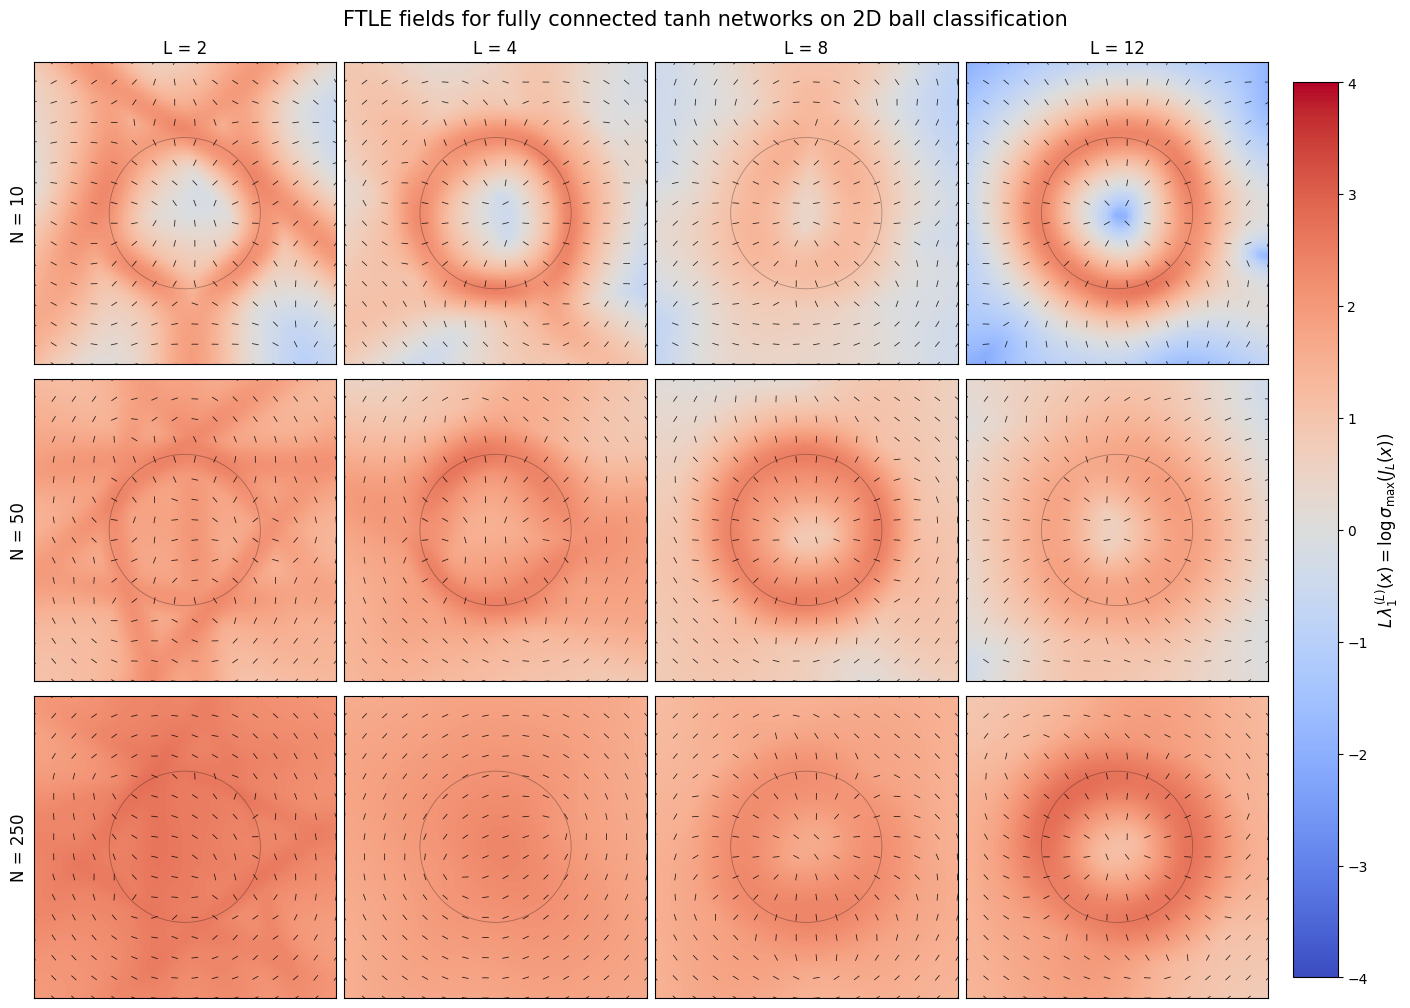

In [13]:
results = main(cfg)

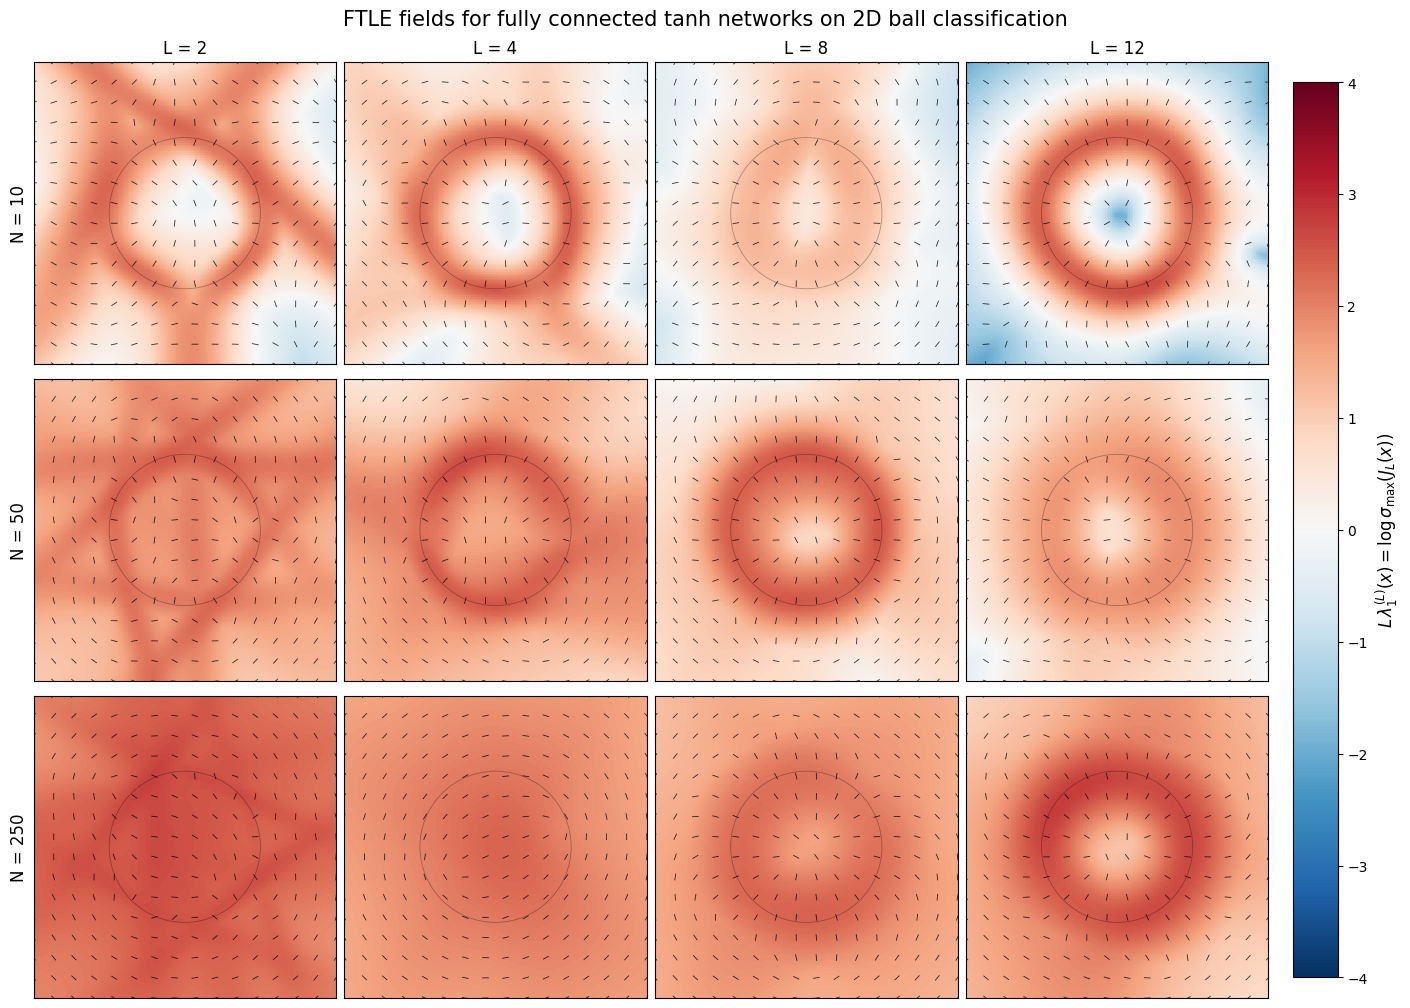

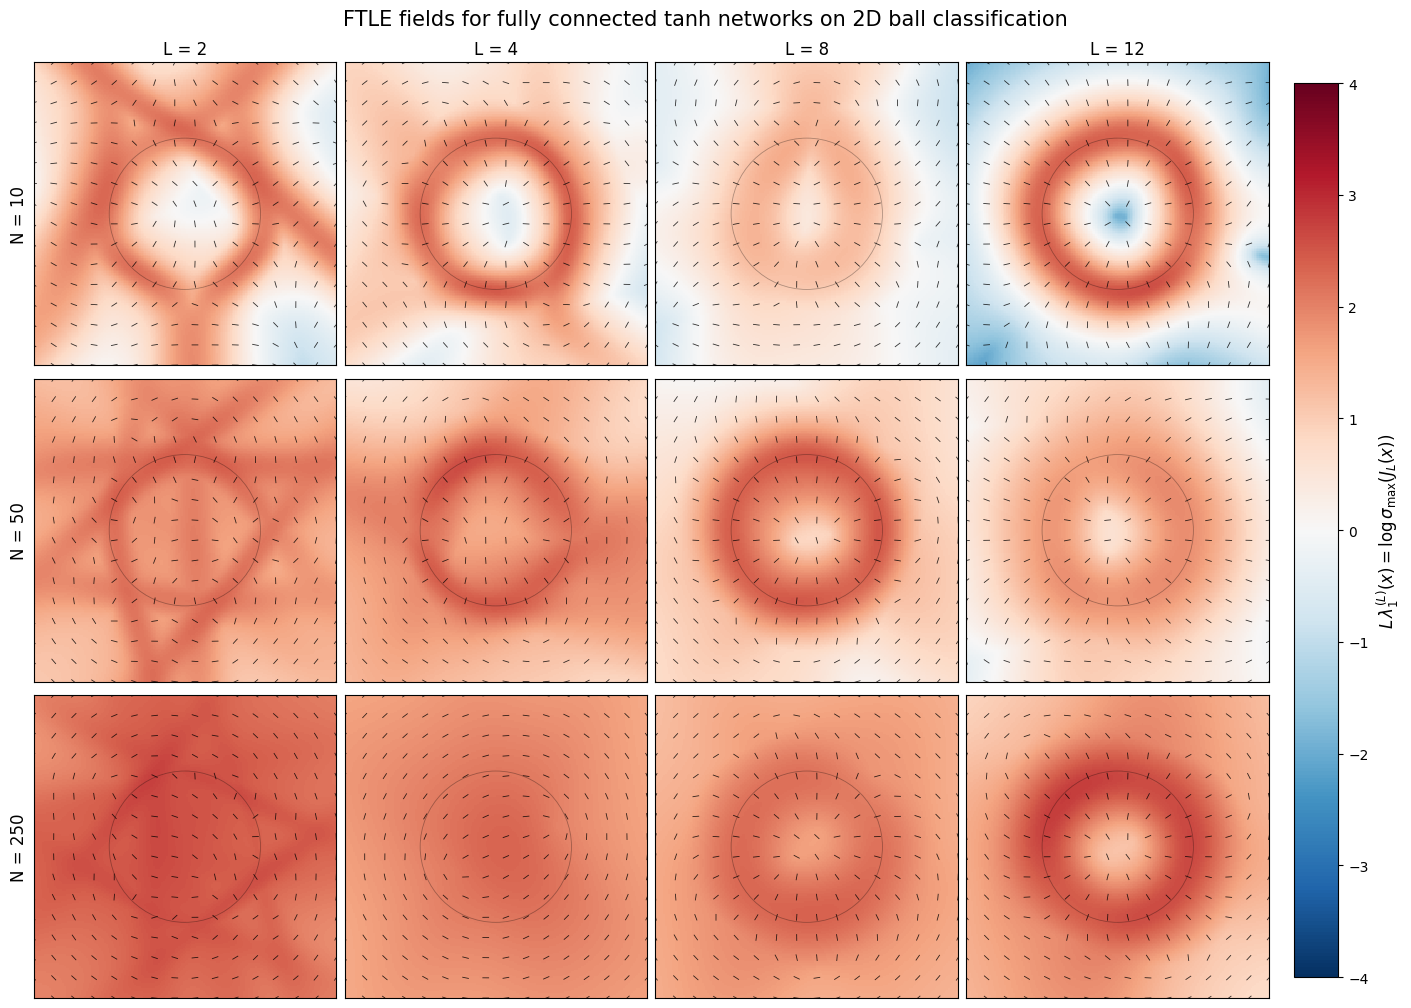

In [16]:
plot_12_tiles(results, cfg)

In [17]:
torch.save(results, 'independent_results_FCNet.pt')